In [1]:
# ============================================================
# CELLULE 1 (V2) : VARIABLES D'ÉMISSIONS AGRÉGÉES
# Corrections :
#   - Filtre : Rachat >= 2015 + PM avec émissions uniquement
#   - Montants = 0 imputés par la médiane du contrat
#   - Ajout variables binaires : hausse (x1.5) et chute (-70%)
#   - Seuils appliqués sur N-1 vs moyenne historique
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats

# ============================================================
# ETAPE 1 : CHARGEMENT
# ============================================================

ec = pd.read_csv('emission_annuelle_complete.csv', sep=None, engine='python')
ec.columns = ec.columns.str.strip().str.replace('\ufeff', '')
ec['ID_Police'] = ec['ID_Police'].astype(str)
ec = ec.sort_values(['ID_Police', 'annee'])

bar = pd.read_csv('Base_annee_rachat.csv', sep=None, engine='python')
bar.columns = bar.columns.str.strip().str.replace('\ufeff', '')
bar['ID_Police'] = bar['ID_Police'].astype(str)

print(f"Émissions brutes       : {len(ec):,} lignes | {ec['ID_Police'].nunique():,} contrats")
print(f"Base contrats          : {bar.shape}")

# ============================================================
# ETAPE 2 : DÉFINITION DU PÉRIMÈTRE
# ============================================================

# Rachat >= 2015 : tous gardés (même sans émissions → imputés à 0 plus tard)
rachat_ids = set(bar[(bar['Rachat'] == 1) & (bar['année de rachat'] >= 2015)]['ID_Police'])

# PM : uniquement ceux présents dans les émissions (les autres sont trop vieux)
emit_ids   = set(ec['ID_Police'])
pm_ids_ok  = set(bar[bar['Rachat'] == 0]['ID_Police']) & emit_ids

contrats_ok = rachat_ids | pm_ids_ok

print(f"\nRachat >= 2015         : {len(rachat_ids):,} contrats")
print(f"PM avec émissions      : {len(pm_ids_ok):,} contrats")
print(f"PM exclus (sans émiss) : {len(set(bar[bar['Rachat']==0]['ID_Police']) - emit_ids):,} contrats")
print(f"Total périmètre ML     : {len(contrats_ok):,} contrats")

# Filtrer les émissions sur le périmètre
ec = ec[ec['ID_Police'].isin(contrats_ok)].copy()
print(f"\nÉmissions après filtre : {len(ec):,} lignes | {ec['ID_Police'].nunique():,} contrats")

# ============================================================
# ETAPE 3 : IMPUTATION DES MONTANTS = 0
# par la médiane du contrat sur ses autres années
# ============================================================

n_zeros_avant = (ec['montant'] == 0).sum()

def imputer_zeros(groupe):
    mediane_nonzero = groupe[groupe > 0].median()
    if pd.isna(mediane_nonzero):
        return groupe  # Contrat avec tous les montants à 0 → on laisse
    return groupe.where(groupe != 0, mediane_nonzero)

ec['montant'] = ec.groupby('ID_Police')['montant'].transform(imputer_zeros)

n_zeros_apres = (ec['montant'] == 0).sum()
print(f"\nMontants = 0 avant imputation : {n_zeros_avant:,}")
print(f"Montants = 0 après imputation : {n_zeros_apres:,} (cas tout-zéro résiduels)")

# ============================================================
# ETAPE 4 : RÉCUPÉRER L'ANNÉE DE RACHAT POUR LES RACHATS
# ============================================================

annee_rachat_map = (
    bar[(bar['Rachat'] == 1) & (bar['année de rachat'] >= 2015)]
    [['ID_Police', 'année de rachat']]
    .drop_duplicates(subset='ID_Police')
    .rename(columns={'année de rachat': 'annee_rachat'})
    .set_index('ID_Police')['annee_rachat']
)

# ============================================================
# ETAPE 5 : CALCUL DES VARIABLES AGRÉGÉES
# ============================================================

def calc_tendance(montants):
    if len(montants) < 2:
        return 0.0
    x = np.arange(len(montants))
    slope, _, _, _, _ = stats.linregress(x, montants)
    return round(slope, 4)

agg = ec.groupby('ID_Police').agg(
    moyenne_versements = ('montant', 'mean'),
    std_versements     = ('montant', 'std'),
    nb_annees_emission = ('annee',   'nunique'),
    dernier_montant    = ('montant', 'last'),
    premier_montant    = ('montant', 'first'),
    montant_total      = ('montant', 'sum'),
).reset_index()

tendance = (
    ec.groupby('ID_Police')['montant']
    .apply(lambda s: calc_tendance(s.values))
    .rename('tendance_versements')
    .reset_index()
)
agg = agg.merge(tendance, on='ID_Police', how='left')

agg['std_versements'] = agg['std_versements'].fillna(0)

agg['ratio_dernier_vs_moyenne'] = np.where(
    agg['moyenne_versements'] > 0,
    agg['dernier_montant'] / agg['moyenne_versements'], 0
)
agg['cv_versements'] = np.where(
    agg['moyenne_versements'] > 0,
    agg['std_versements'] / agg['moyenne_versements'], 0
)

print(f"\nVariables agrégées calculées pour {len(agg):,} contrats")

# ============================================================
# ETAPE 6 : VARIABLES BINAIRES HAUSSE / CHUTE (RACHATS UNIQUEMENT)
# Hausse  : montant N-1 >= 1.5x moyenne historique
# Chute   : montant N-1 <= 0.30x moyenne historique (baisse >= 70%)
# PM      : 0 par défaut
# ============================================================

ec_rachat = ec[ec['ID_Police'].isin(rachat_ids)].copy()
ec_rachat['annee_rachat'] = ec_rachat['ID_Police'].map(annee_rachat_map)
ec_rachat['annee_N1']     = ec_rachat['annee_rachat'] - 1

hist = (
    ec_rachat[ec_rachat['annee'] < ec_rachat['annee_N1']]
    .groupby('ID_Police')['montant'].mean()
    .rename('moyenne_historique')
)
n1 = (
    ec_rachat[ec_rachat['annee'] == ec_rachat['annee_N1']]
    .groupby('ID_Police')['montant'].sum()
    .rename('montant_N1')
)

seuils = pd.DataFrame(index=list(rachat_ids))
seuils.index.name = 'ID_Police'
seuils = seuils.join(hist).join(n1)

both = seuils['moyenne_historique'].notna() & seuils['montant_N1'].notna()
seuils.loc[both, 'ratio_N1_vs_hist'] = (
    seuils.loc[both, 'montant_N1'] / seuils.loc[both, 'moyenne_historique']
)
seuils['hausse_exceptionnelle'] = (both & (seuils['ratio_N1_vs_hist'] >= 1.5)).astype(int)
seuils['chute_brutale']         = (both & (seuils['ratio_N1_vs_hist'] <= 0.30)).astype(int)
seuils = seuils[['hausse_exceptionnelle', 'chute_brutale']].reset_index()

print(f"\nHausse exceptionnelle (Rachat) : {seuils['hausse_exceptionnelle'].sum():,}")
print(f"Chute brutale (Rachat)         : {seuils['chute_brutale'].sum():,}")

agg = agg.merge(seuils, on='ID_Police', how='left')
agg['hausse_exceptionnelle'] = agg['hausse_exceptionnelle'].fillna(0).astype(int)
agg['chute_brutale']         = agg['chute_brutale'].fillna(0).astype(int)

# ============================================================
# ETAPE 7 : CONTRATS RACHAT SANS ÉMISSIONS → IMPUTER À 0
# ============================================================

rachat_sans_emit = rachat_ids - emit_ids
if rachat_sans_emit:
    rows_manquants = pd.DataFrame({'ID_Police': list(rachat_sans_emit)})
    for col in [c for c in agg.columns if c != 'ID_Police']:
        rows_manquants[col] = 0
    agg = pd.concat([agg, rows_manquants], ignore_index=True)
    print(f"\nContrats rachat sans émissions ajoutés avec 0 : {len(rachat_sans_emit):,}")

# ============================================================
# ETAPE 8 : RÉSUMÉ ET EXPORT
# ============================================================

print(f"\nDataset émissions final : {len(agg):,} contrats | {agg.shape[1]} variables")
print(f"Valeurs manquantes      : {agg.isnull().sum().sum()}")
print(f"\nColonnes : {list(agg.columns)}")

agg.to_csv('features_emissions.csv', index=False)
print("\nFichier sauvegardé : features_emissions.csv")

Émissions brutes       : 515,563 lignes | 123,049 contrats
Base contrats          : (122753, 19)

Rachat >= 2015         : 49,419 contrats
PM avec émissions      : 69,694 contrats
PM exclus (sans émiss) : 553 contrats
Total périmètre ML     : 112,507 contrats

Émissions après filtre : 493,995 lignes | 112,245 contrats

Montants = 0 avant imputation : 8,040
Montants = 0 après imputation : 34 (cas tout-zéro résiduels)

Variables agrégées calculées pour 112,245 contrats

Hausse exceptionnelle (Rachat) : 9,589
Chute brutale (Rachat)         : 1,184

Contrats rachat sans émissions ajoutés avec 0 : 262

Dataset émissions final : 112,507 contrats | 12 variables
Valeurs manquantes      : 0

Colonnes : ['ID_Police', 'moyenne_versements', 'std_versements', 'nb_annees_emission', 'dernier_montant', 'premier_montant', 'montant_total', 'tendance_versements', 'ratio_dernier_vs_moyenne', 'cv_versements', 'hausse_exceptionnelle', 'chute_brutale']

Fichier sauvegardé : features_emissions.csv


In [3]:
# ============================================================
# CELLULE 2 (V2) : FEATURE ENGINEERING SUR BASE_ANNEE_RACHAT
# Corrections :
#   - Suppression de TMP_ANNUITY_TERM
#   - Filtre : Rachat >= 2015 + PM avec émissions uniquement
#   - Annee_Effet supprimé (redondant avec Anciennete)
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# CHARGEMENT
# ============================================================

bar = pd.read_csv('Base_annee_rachat.csv', sep=None, engine='python')
bar.columns = bar.columns.str.strip().str.replace('\ufeff', '')
bar['ID_Police'] = bar['ID_Police'].astype(str)

ec = pd.read_csv('emission_annuelle_complete.csv', sep=None, engine='python')
ec.columns = ec.columns.str.strip().str.replace('\ufeff', '')
ec['ID_Police'] = ec['ID_Police'].astype(str)
emit_ids = set(ec['ID_Police'])

print(f"Base chargée : {bar.shape}")

# ============================================================
# ETAPE 1 : FILTRE SUR LE PÉRIMÈTRE ML
# ============================================================

rachat_ok = (bar['Rachat'] == 1) & (bar['année de rachat'] >= 2015)
pm_ok     = (bar['Rachat'] == 0) & (bar['ID_Police'].isin(emit_ids))

bar = bar[rachat_ok | pm_ok].copy()
bar = bar.drop_duplicates(subset='ID_Police')

print(f"Après filtre périmètre ML : {len(bar):,} contrats")
print(f"  Rachat >= 2015 : {rachat_ok.sum():,}")
print(f"  PM avec émiss  : {pm_ok.sum():,}")

# ============================================================
# ETAPE 2 : SUPPRESSION DES COLONNES NON INFORMATIVES
# ============================================================

cols_a_supprimer = [
    'Date_Naissance',    # remplacée par Age
    'Debut',             # remplacée par Anciennete
    'Fin',               # non informative pour ML
    'Annee_Effet',       # redondant avec Anciennete
    'TMP_ANNUITY_TERM',  # supprimé à la demande
    'Ville',             # trop granulaire
    'Beneficiaires',     # texte libre
    'année de rachat',   # info post-événement
]

bar = bar.drop(columns=cols_a_supprimer)
print(f"\nAprès suppression colonnes : {bar.shape}")

# ============================================================
# ETAPE 3 : GESTION DES VALEURS MANQUANTES
# ============================================================

print(f"\nValeurs manquantes avant traitement :\n{bar.isnull().sum()[bar.isnull().sum() > 0]}")

for col in ['Montant_Initial_Versement', 'Montant_Regulier', 'Frequence', 'Code_Postal']:
    if col in bar.columns:
        bar[col] = bar[col].fillna(bar[col].median())

for col in ['Type_versement']:
    if col in bar.columns:
        bar[col] = bar[col].fillna(bar[col].mode()[0])

bar['Agence'] = bar['Agence'].fillna('Inconnue')

print(f"\nValeurs manquantes après traitement : {bar.isnull().sum().sum()}")

# ============================================================
# ETAPE 4 : ENCODAGE DES VARIABLES CATÉGORIELLES
# ============================================================

# Type_versement : P=1, L=0
bar['type_versement_P'] = (bar['Type_versement'] == 'P').astype(int)
bar = bar.drop(columns=['Type_versement'])

# Code_Postal : trop de modalités → supprimé
bar = bar.drop(columns=['Code_Postal'])

# Agence : frequency encoding
freq_agence = bar['Agence'].value_counts(normalize=True)
bar['agence_freq'] = bar['Agence'].map(freq_agence)
bar = bar.drop(columns=['Agence'])

print(f"\nColonnes finales ({bar.shape[1]}) : {list(bar.columns)}")
print(f"\nAperçu :\n{bar.head(3).to_string()}")
print(f"\nValeurs manquantes finale : {bar.isnull().sum().sum()}")

# ============================================================
# EXPORT
# ============================================================

bar.to_csv('features_base.csv', index=False)
print("\nFichier sauvegardé : features_base.csv")

Base chargée : (122753, 19)
Après filtre périmètre ML : 112,507 contrats
  Rachat >= 2015 : 49,513
  PM avec émiss  : 69,694

Après suppression colonnes : (112507, 11)

Valeurs manquantes avant traitement :
Montant_Initial_Versement     17
Montant_Regulier              17
Type_versement                17
Frequence                     17
Code_Postal                   17
Agence                       430
dtype: int64

Valeurs manquantes après traitement : 0

Colonnes finales (10) : ['ID_Police', 'Montant_Initial_Versement', 'Montant_Regulier', 'Frequence', 'Age', 'Anciennete', 'Charge_Finale', 'Rachat', 'type_versement_P', 'agence_freq']

Aperçu :
           ID_Police  Montant_Initial_Versement  Montant_Regulier  Frequence  Age  Anciennete  Charge_Finale  Rachat  type_versement_P  agence_freq
2834   1401062009607                      100.0             100.0       12.0   45           9        7461.61       1                 1     0.010737
2835  14010900000353                      100.0    

Dataset fusionné : (112507, 21)
Valeurs manquantes : 0

Features : 19 | Observations : 112,507
Taux de rachat : 43.9%

=== Corrélation absolue avec Rachat ===
hausse_exceptionnelle        0.3449
type_versement_P             0.2792
Anciennete                   0.2651
Frequence                    0.2288
ratio_dernier_vs_moyenne     0.1921
Age                          0.1574
chute_brutale                0.1165
nb_annees_emission           0.0833
montant_total                0.0688
std_versements               0.0456
Charge_Finale                0.0439
agence_freq                  0.0269
moyenne_versements           0.0107
cv_versements                0.0093
tendance_versements          0.0076
premier_montant              0.0074
Montant_Initial_Versement    0.0037
Montant_Regulier             0.0015
dernier_montant              0.0000

Variables avec corrélation >= 0.02 : 12
['hausse_exceptionnelle', 'type_versement_P', 'Anciennete', 'Frequence', 'ratio_dernier_vs_moyenne', 'Age', 'chute_b

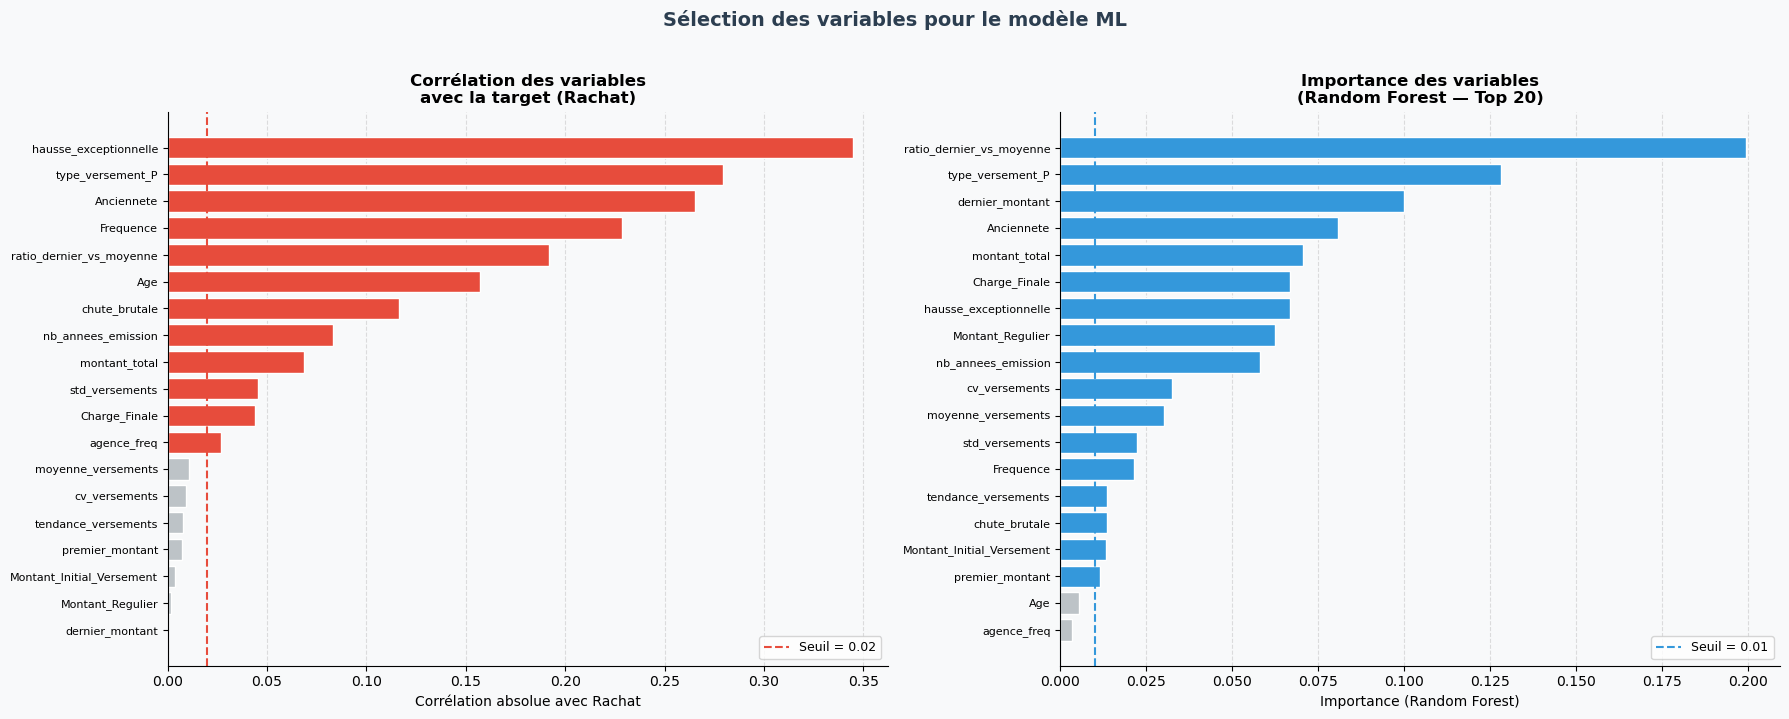

Graphique sauvegardé : selection_variables.png


In [5]:
# ============================================================
# CELLULE 3 : SÉLECTION DES VARIABLES
# Corrélation + Importance Random Forest
# Seuil : importance >= 0.01 (1%)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# ============================================================
# CHARGEMENT ET FUSION
# ============================================================

base     = pd.read_csv('features_base.csv')
base['ID_Police'] = base['ID_Police'].astype(str)

emissions = pd.read_csv('features_emissions.csv')
emissions['ID_Police'] = emissions['ID_Police'].astype(str)

df = base.merge(emissions, on='ID_Police', how='left')

# Remplir NaN d'émissions (contrats sans aucune émission) par 0
cols_emissions = [c for c in emissions.columns if c != 'ID_Police']
df[cols_emissions] = df[cols_emissions].fillna(0)

print(f"Dataset fusionné : {df.shape}")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")

# ============================================================
# PREPARATION X / y
# ============================================================

target   = 'Rachat'
drop_cols = ['ID_Police', target]
X = df.drop(columns=drop_cols)
y = df[target]

print(f"\nFeatures : {X.shape[1]} | Observations : {X.shape[0]:,}")
print(f"Taux de rachat : {y.mean()*100:.1f}%")

# ============================================================
# ETAPE 1 : MATRICE DE CORRÉLATION AVEC LA TARGET
# ============================================================

corr_target = X.corrwith(y).abs().sort_values(ascending=False)
print("\n=== Corrélation absolue avec Rachat ===")
print(corr_target.round(4).to_string())

SEUIL_CORR = 0.02  # seuil minimal de corrélation avec la target
vars_corr_ok = corr_target[corr_target >= SEUIL_CORR].index.tolist()
print(f"\nVariables avec corrélation >= {SEUIL_CORR} : {len(vars_corr_ok)}")
print(vars_corr_ok)

# ============================================================
# ETAPE 2 : IMPORTANCE RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\n=== Importance Random Forest ===")
print(importances.round(4).to_string())

SEUIL_IMP = 0.01  # seuil minimal d'importance
vars_imp_ok = importances[importances >= SEUIL_IMP].index.tolist()
print(f"\nVariables avec importance >= {SEUIL_IMP} : {len(vars_imp_ok)}")
print(vars_imp_ok)

# ============================================================
# ETAPE 3 : SÉLECTION FINALE — UNION DES DEUX CRITÈRES
# ============================================================

vars_selectionnees = list(set(vars_corr_ok) | set(vars_imp_ok))
vars_selectionnees.sort()
print(f"\n=== Variables sélectionnées (union corrélation + importance) : {len(vars_selectionnees)} ===")
print(vars_selectionnees)

# Sauvegarde de la liste
pd.Series(vars_selectionnees).to_csv('variables_selectionnees.csv', index=False, header=['variable'])
print("\nFichier sauvegardé : variables_selectionnees.csv")

# ============================================================
# ETAPE 4 : VISUALISATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#F8F9FA')

# --- Graphique 1 : Corrélation avec la target ---
ax1 = axes[0]
ax1.set_facecolor('#F8F9FA')
colors_corr = ['#E74C3C' if v >= SEUIL_CORR else '#BDC3C7' for v in corr_target.values]
bars1 = ax1.barh(corr_target.index[::-1], corr_target.values[::-1],
                 color=colors_corr[::-1], edgecolor='white')
ax1.axvline(x=SEUIL_CORR, color='#E74C3C', linestyle='--', linewidth=1.5,
            label=f'Seuil = {SEUIL_CORR}')
ax1.set_xlabel('Corrélation absolue avec Rachat', fontsize=10)
ax1.set_title('Corrélation des variables\navec la target (Rachat)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.xaxis.grid(True, linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)
ax1.tick_params(axis='y', labelsize=8)

# --- Graphique 2 : Importance Random Forest ---
ax2 = axes[1]
ax2.set_facecolor('#F8F9FA')
top_imp = importances.head(20)
colors_imp = ['#3498DB' if v >= SEUIL_IMP else '#BDC3C7' for v in top_imp.values]
ax2.barh(top_imp.index[::-1], top_imp.values[::-1],
         color=colors_imp[::-1], edgecolor='white')
ax2.axvline(x=SEUIL_IMP, color='#3498DB', linestyle='--', linewidth=1.5,
            label=f'Seuil = {SEUIL_IMP}')
ax2.set_xlabel('Importance (Random Forest)', fontsize=10)
ax2.set_title('Importance des variables\n(Random Forest — Top 20)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.xaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)
ax2.tick_params(axis='y', labelsize=8)

plt.suptitle('Sélection des variables pour le modèle ML',
             fontsize=14, fontweight='bold', color='#2C3E50', y=1.02)
plt.tight_layout()
plt.savefig('selection_variables.png', dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Graphique sauvegardé : selection_variables.png")

In [7]:
# ============================================================
# CELLULE 4 : CONSTRUCTION DU DATASET ML FINAL
# Fusion de toutes les features sélectionnées
# Export du fichier prêt pour la modélisation
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# CHARGEMENT
# ============================================================

base      = pd.read_csv('features_base.csv')
base['ID_Police'] = base['ID_Police'].astype(str)

emissions = pd.read_csv('features_emissions.csv')
emissions['ID_Police'] = emissions['ID_Police'].astype(str)

vars_sel  = pd.read_csv('variables_selectionnees.csv')['variable'].tolist()

# ============================================================
# FUSION COMPLÈTE
# ============================================================

df = base.merge(emissions, on='ID_Police', how='left')

# Remplir NaN d'émissions par 0 (contrats sans émissions connues)
cols_emissions = [c for c in emissions.columns if c != 'ID_Police']
df[cols_emissions] = df[cols_emissions].fillna(0)

print(f"Dataset complet fusionné : {df.shape}")

# ============================================================
# SÉLECTION DES VARIABLES RETENUES
# ============================================================

# On garde ID_Police + target + variables sélectionnées
cols_finales = ['ID_Police', 'Rachat'] + [v for v in vars_sel if v in df.columns]
df_ml = df[cols_finales].copy()

print(f"Dataset ML final         : {df_ml.shape}")
print(f"Variables retenues       : {len(vars_sel)}")
print(f"Target (Rachat)          : {df_ml['Rachat'].value_counts().to_dict()}")
print(f"Taux de rachat           : {df_ml['Rachat'].mean()*100:.1f}%")
print(f"\nValeurs manquantes       : {df_ml.isnull().sum().sum()}")
print(f"\nColonnes finales :\n{list(df_ml.columns)}")

# ============================================================
# STATISTIQUES DESCRIPTIVES PAR GROUPE
# ============================================================

print("\n=== Moyennes par groupe (Rachat 0 vs 1) ===")
print(df_ml.groupby('Rachat')[vars_sel].mean().round(3).T.to_string())

# ============================================================
# EXPORT
# ============================================================

# Dataset ML complet (avec ID_Police pour traçabilité)
df_ml.to_csv('dataset_ml_final.csv', index=False)
print("\nFichier sauvegardé : dataset_ml_final.csv")

# Dataset sans ID pour modélisation directe
df_ml.drop(columns=['ID_Police']).to_csv('dataset_ml_modelisation.csv', index=False)
print("Fichier sauvegardé : dataset_ml_modelisation.csv")

print("\n" + "="*55)
print("DATASET ML PRÊT — Prochaine étape : modélisation")
print("="*55)
print(f"  Observations : {len(df_ml):,}")
print(f"  Features     : {len(vars_sel)}")
print(f"  Target       : Rachat (0 = PM, 1 = Rachat)")

Dataset complet fusionné : (112507, 21)
Dataset ML final         : (112507, 21)
Variables retenues       : 19
Target (Rachat)          : {0: 63088, 1: 49419}
Taux de rachat           : 43.9%

Valeurs manquantes       : 0

Colonnes finales :
['ID_Police', 'Rachat', 'Age', 'Anciennete', 'Charge_Finale', 'Frequence', 'Montant_Initial_Versement', 'Montant_Regulier', 'agence_freq', 'chute_brutale', 'cv_versements', 'dernier_montant', 'hausse_exceptionnelle', 'montant_total', 'moyenne_versements', 'nb_annees_emission', 'premier_montant', 'ratio_dernier_vs_moyenne', 'std_versements', 'tendance_versements', 'type_versement_P']

=== Moyennes par groupe (Rachat 0 vs 1) ===
Rachat                            0         1
Age                          45.266    41.897
Anciennete                    5.643     3.836
Charge_Finale              6117.189  4270.501
Frequence                     8.940    10.956
Montant_Initial_Versement  1492.776  1414.673
Montant_Regulier             83.515    81.700
agence

PermissionError: [Errno 13] Permission denied: 'dataset_ml_final.csv'

Dataset : 122,753 observations | 18 features
Taux de rachat : 42.8%

Train : 98,202 | Test : 24,551
Taux rachat train : 42.8% | test : 42.8%

Entraînement : Régression Logistique
  AUC-ROC        : 0.8421
  F1-Score       : 0.7255
  Accuracy       : 0.7587
  Précision      : 0.7066
  Rappel         : 0.7455
  CV AUC (5-fold): 0.8398 ± 0.0027

  Rapport de classification :
              precision    recall  f1-score   support

      PM (0)     0.8016    0.7686    0.7848     14050
  Rachat (1)     0.7066    0.7455    0.7255     10501

    accuracy                         0.7587     24551
   macro avg     0.7541    0.7570    0.7551     24551
weighted avg     0.7609    0.7587    0.7594     24551


Entraînement : Random Forest
  AUC-ROC        : 0.9691
  F1-Score       : 0.8943
  Accuracy       : 0.9096
  Précision      : 0.8944
  Rappel         : 0.8941
  CV AUC (5-fold): 0.9681 ± 0.0003

  Rapport de classification :
              precision    recall  f1-score   support

      PM (0)     

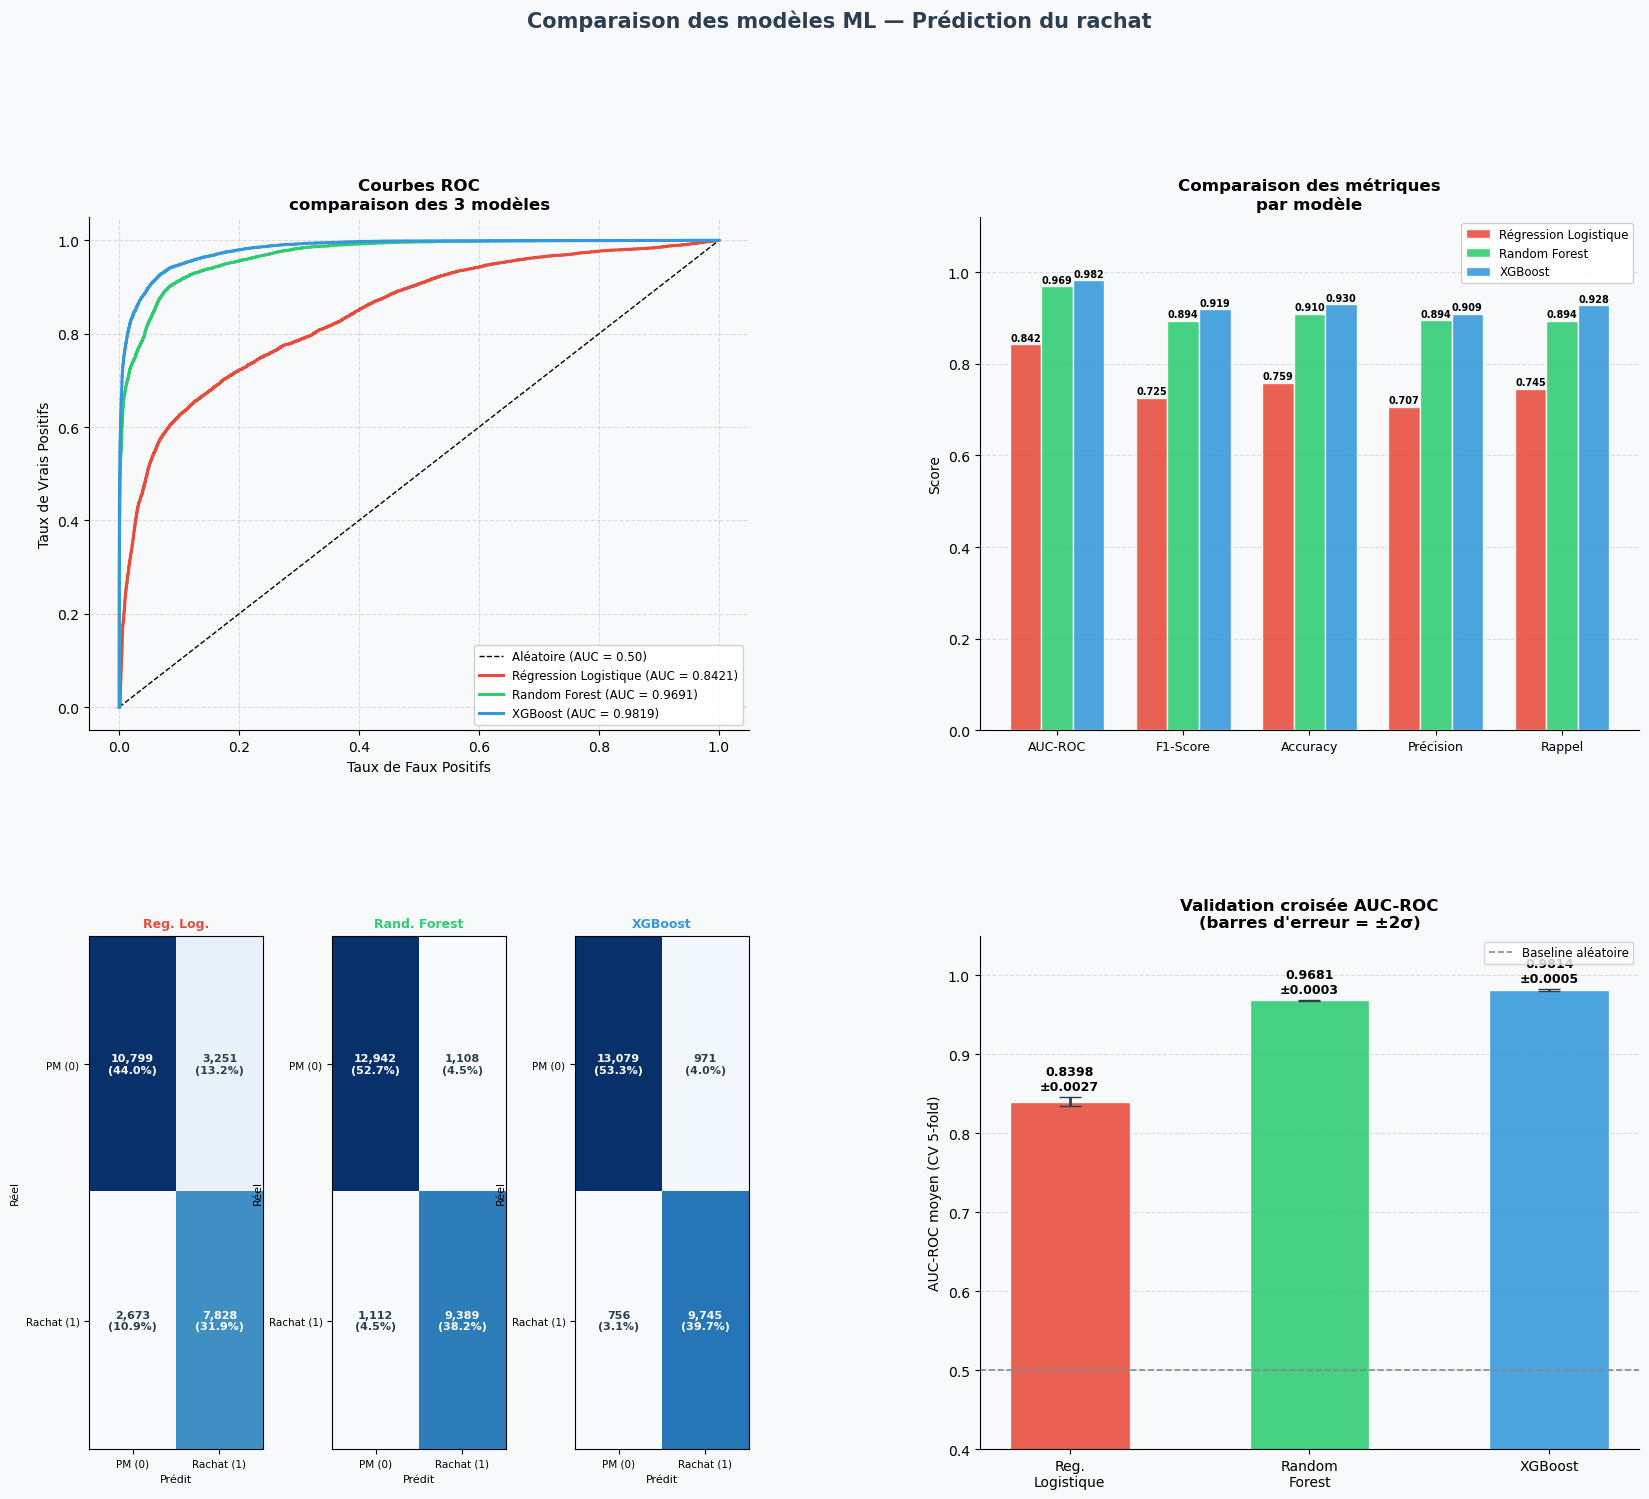

Graphique sauvegardé : comparaison_modeles.png


In [9]:
# ============================================================
# CELLULE 5 : ENTRAÎNEMENT ET COMPARAISON DES 3 MODÈLES
# Logistic Regression / Random Forest / XGBoost
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, precision_score,
    recall_score, confusion_matrix, roc_curve, classification_report
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CHARGEMENT DU DATASET ML
# ============================================================

df = pd.read_csv('dataset_ml_modelisation.csv')

X = df.drop(columns=['Rachat'])
y = df['Rachat']

print(f"Dataset : {X.shape[0]:,} observations | {X.shape[1]} features")
print(f"Taux de rachat : {y.mean()*100:.1f}%")

# ============================================================
# SPLIT TRAIN / TEST — stratifié pour respecter l'équilibre
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain : {len(X_train):,} | Test : {len(X_test):,}")
print(f"Taux rachat train : {y_train.mean()*100:.1f}% | test : {y_test.mean()*100:.1f}%")

# ============================================================
# NORMALISATION (nécessaire pour la Régression Logistique)
# ============================================================

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ============================================================
# DÉFINITION DES MODÈLES
# ============================================================

ratio_classes = (y == 0).sum() / (y == 1).sum()

modeles = {
    'Régression Logistique': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio_classes,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
}

# ============================================================
# ENTRAÎNEMENT + ÉVALUATION
# ============================================================

resultats = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nom, modele in modeles.items():
    print(f"\n{'='*50}")
    print(f"Entraînement : {nom}")
    print('='*50)

    # Données normalisées pour LR, brutes pour RF et XGB
    if nom == 'Régression Logistique':
        Xtr, Xte = X_train_sc, X_test_sc
    else:
        Xtr, Xte = X_train, X_test

    # Entraînement
    modele.fit(Xtr, y_train)

    # Prédictions
    y_pred      = modele.predict(Xte)
    y_proba     = modele.predict_proba(Xte)[:, 1]

    # Métriques
    auc         = roc_auc_score(y_test, y_proba)
    f1          = f1_score(y_test, y_pred)
    acc         = accuracy_score(y_test, y_pred)
    precision   = precision_score(y_test, y_pred)
    recall      = recall_score(y_test, y_pred)
    cm          = confusion_matrix(y_test, y_pred)

    # Cross-validation AUC (5 folds)
    cv_auc = cross_val_score(modele, Xtr, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)

    resultats[nom] = {
        'modele'    : modele,
        'y_pred'    : y_pred,
        'y_proba'   : y_proba,
        'auc'       : auc,
        'f1'        : f1,
        'accuracy'  : acc,
        'precision' : precision,
        'recall'    : recall,
        'cm'        : cm,
        'cv_auc_mean': cv_auc.mean(),
        'cv_auc_std' : cv_auc.std(),
    }

    print(f"  AUC-ROC        : {auc:.4f}")
    print(f"  F1-Score       : {f1:.4f}")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  Précision      : {precision:.4f}")
    print(f"  Rappel         : {recall:.4f}")
    print(f"  CV AUC (5-fold): {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
    print(f"\n  Rapport de classification :")
    print(classification_report(y_test, y_pred,
          target_names=['PM (0)', 'Rachat (1)'], digits=4))

# ============================================================
# TABLEAU COMPARATIF
# ============================================================

print("\n" + "="*65)
print("TABLEAU COMPARATIF DES MODÈLES")
print("="*65)
compare = pd.DataFrame({
    nom: {
        'AUC-ROC'         : f"{r['auc']:.4f}",
        'F1-Score'        : f"{r['f1']:.4f}",
        'Accuracy'        : f"{r['accuracy']:.4f}",
        'Précision'       : f"{r['precision']:.4f}",
        'Rappel'          : f"{r['recall']:.4f}",
        'CV AUC (mean)'   : f"{r['cv_auc_mean']:.4f}",
        'CV AUC (±std)'   : f"{r['cv_auc_std']:.4f}",
    }
    for nom, r in resultats.items()
}).T
print(compare.to_string())

# ============================================================
# VISUALISATION — 4 graphiques
# ============================================================

COLORS = {
    'Régression Logistique' : '#E74C3C',
    'Random Forest'         : '#2ECC71',
    'XGBoost'               : '#3498DB',
}

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#F8F9FA')
gs_main = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

# ------------------------------------------------------------------
# GRAPHIQUE 1 : Courbes ROC
# ------------------------------------------------------------------
ax1 = fig.add_subplot(gs_main[0, 0])
ax1.set_facecolor('#F8F9FA')

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.50)')
for nom, r in resultats.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax1.plot(fpr, tpr, color=COLORS[nom], linewidth=2.2,
             label=f"{nom} (AUC = {r['auc']:.4f})")

ax1.set_xlabel('Taux de Faux Positifs', fontsize=10)
ax1.set_ylabel('Taux de Vrais Positifs', fontsize=10)
ax1.set_title('Courbes ROC\ncomparaison des 3 modèles', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8.5, framealpha=0.9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, linestyle='--', alpha=0.4)

# ------------------------------------------------------------------
# GRAPHIQUE 2 : Comparaison des métriques (barres groupées)
# ------------------------------------------------------------------
ax2 = fig.add_subplot(gs_main[0, 1])
ax2.set_facecolor('#F8F9FA')

metriques  = ['AUC-ROC', 'F1-Score', 'Accuracy', 'Précision', 'Rappel']
metrique_keys = ['auc', 'f1', 'accuracy', 'precision', 'recall']
noms       = list(resultats.keys())
x          = np.arange(len(metriques))
width      = 0.25

for i, nom in enumerate(noms):
    vals = [resultats[nom][k] for k in metrique_keys]
    bars = ax2.bar(x + i * width, vals, width,
                   color=COLORS[nom], label=nom, edgecolor='white', alpha=0.88)
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax2.set_xticks(x + width)
ax2.set_xticklabels(metriques, fontsize=9)
ax2.set_ylim(0, 1.12)
ax2.set_ylabel('Score', fontsize=10)
ax2.set_title('Comparaison des métriques\npar modèle', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8.5, framealpha=0.9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)

# ------------------------------------------------------------------
# GRAPHIQUE 3 : Matrices de confusion (3 sous-graphes)
# ------------------------------------------------------------------
gs_cm = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_main[1, 0],
                                          wspace=0.4)
for i, (nom, r) in enumerate(resultats.items()):
    ax_cm = fig.add_subplot(gs_cm[i])
    ax_cm.set_facecolor('#F8F9FA')
    cm = r['cm']
    im = ax_cm.imshow(cm, interpolation='nearest',
                      cmap=plt.cm.Blues, aspect='auto')

    total = cm.sum()
    for row in range(2):
        for col in range(2):
            val  = cm[row, col]
            pct  = val / total * 100
            color = 'white' if cm[row, col] > cm.max() / 2 else '#2C3E50'
            ax_cm.text(col, row, f'{val:,}\n({pct:.1f}%)',
                       ha='center', va='center', fontsize=8,
                       fontweight='bold', color=color)

    ax_cm.set_xticks([0, 1])
    ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(['PM (0)', 'Rachat (1)'], fontsize=7.5)
    ax_cm.set_yticklabels(['PM (0)', 'Rachat (1)'], fontsize=7.5)
    ax_cm.set_xlabel('Prédit', fontsize=8)
    ax_cm.set_ylabel('Réel', fontsize=8)

    # Nom du modèle abrégé
    nom_court = nom.replace('Régression Logistique', 'Reg. Log.')\
                   .replace('Random Forest', 'Rand. Forest')
    ax_cm.set_title(nom_court, fontsize=9, fontweight='bold',
                    color=COLORS[nom])

# ------------------------------------------------------------------
# GRAPHIQUE 4 : CV AUC avec intervalle de confiance
# ------------------------------------------------------------------
ax4 = fig.add_subplot(gs_main[1, 1])
ax4.set_facecolor('#F8F9FA')

noms_short = ['Reg.\nLogistique', 'Random\nForest', 'XGBoost']
cv_means   = [resultats[n]['cv_auc_mean'] for n in noms]
cv_stds    = [resultats[n]['cv_auc_std']  for n in noms]
colors_list = [COLORS[n] for n in noms]

bars4 = ax4.bar(noms_short, cv_means, color=colors_list,
                edgecolor='white', width=0.5, alpha=0.88)
ax4.errorbar(noms_short, cv_means, yerr=[2*s for s in cv_stds],
             fmt='none', color='#2C3E50', capsize=8, linewidth=2)

for bar, mean, std in zip(bars4, cv_means, cv_stds):
    ax4.text(bar.get_x() + bar.get_width()/2, mean + 2*std + 0.005,
             f'{mean:.4f}\n±{std:.4f}', ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax4.axhline(y=0.5, color='#7F8C8D', linestyle='--',
            linewidth=1.2, label='Baseline aléatoire')
ax4.set_ylim(0.4, 1.05)
ax4.set_ylabel('AUC-ROC moyen (CV 5-fold)', fontsize=10)
ax4.set_title('Validation croisée AUC-ROC\n(barres d\'erreur = ±2σ)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=8.5)
ax4.spines[['top', 'right']].set_visible(False)
ax4.yaxis.grid(True, linestyle='--', alpha=0.4)
ax4.set_axisbelow(True)

# ------------------------------------------------------------------
# TITRE GÉNÉRAL
# ------------------------------------------------------------------
fig.suptitle('Comparaison des modèles ML — Prédiction du rachat',
             fontsize=15, fontweight='bold', color='#2C3E50', y=1.01)

plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Graphique sauvegardé : comparaison_modeles.png")

Meilleur modèle : XGBoost
AUC-ROC         : 0.9819

Calcul des valeurs SHAP (peut prendre 1-2 minutes)...
Valeurs SHAP calculées.


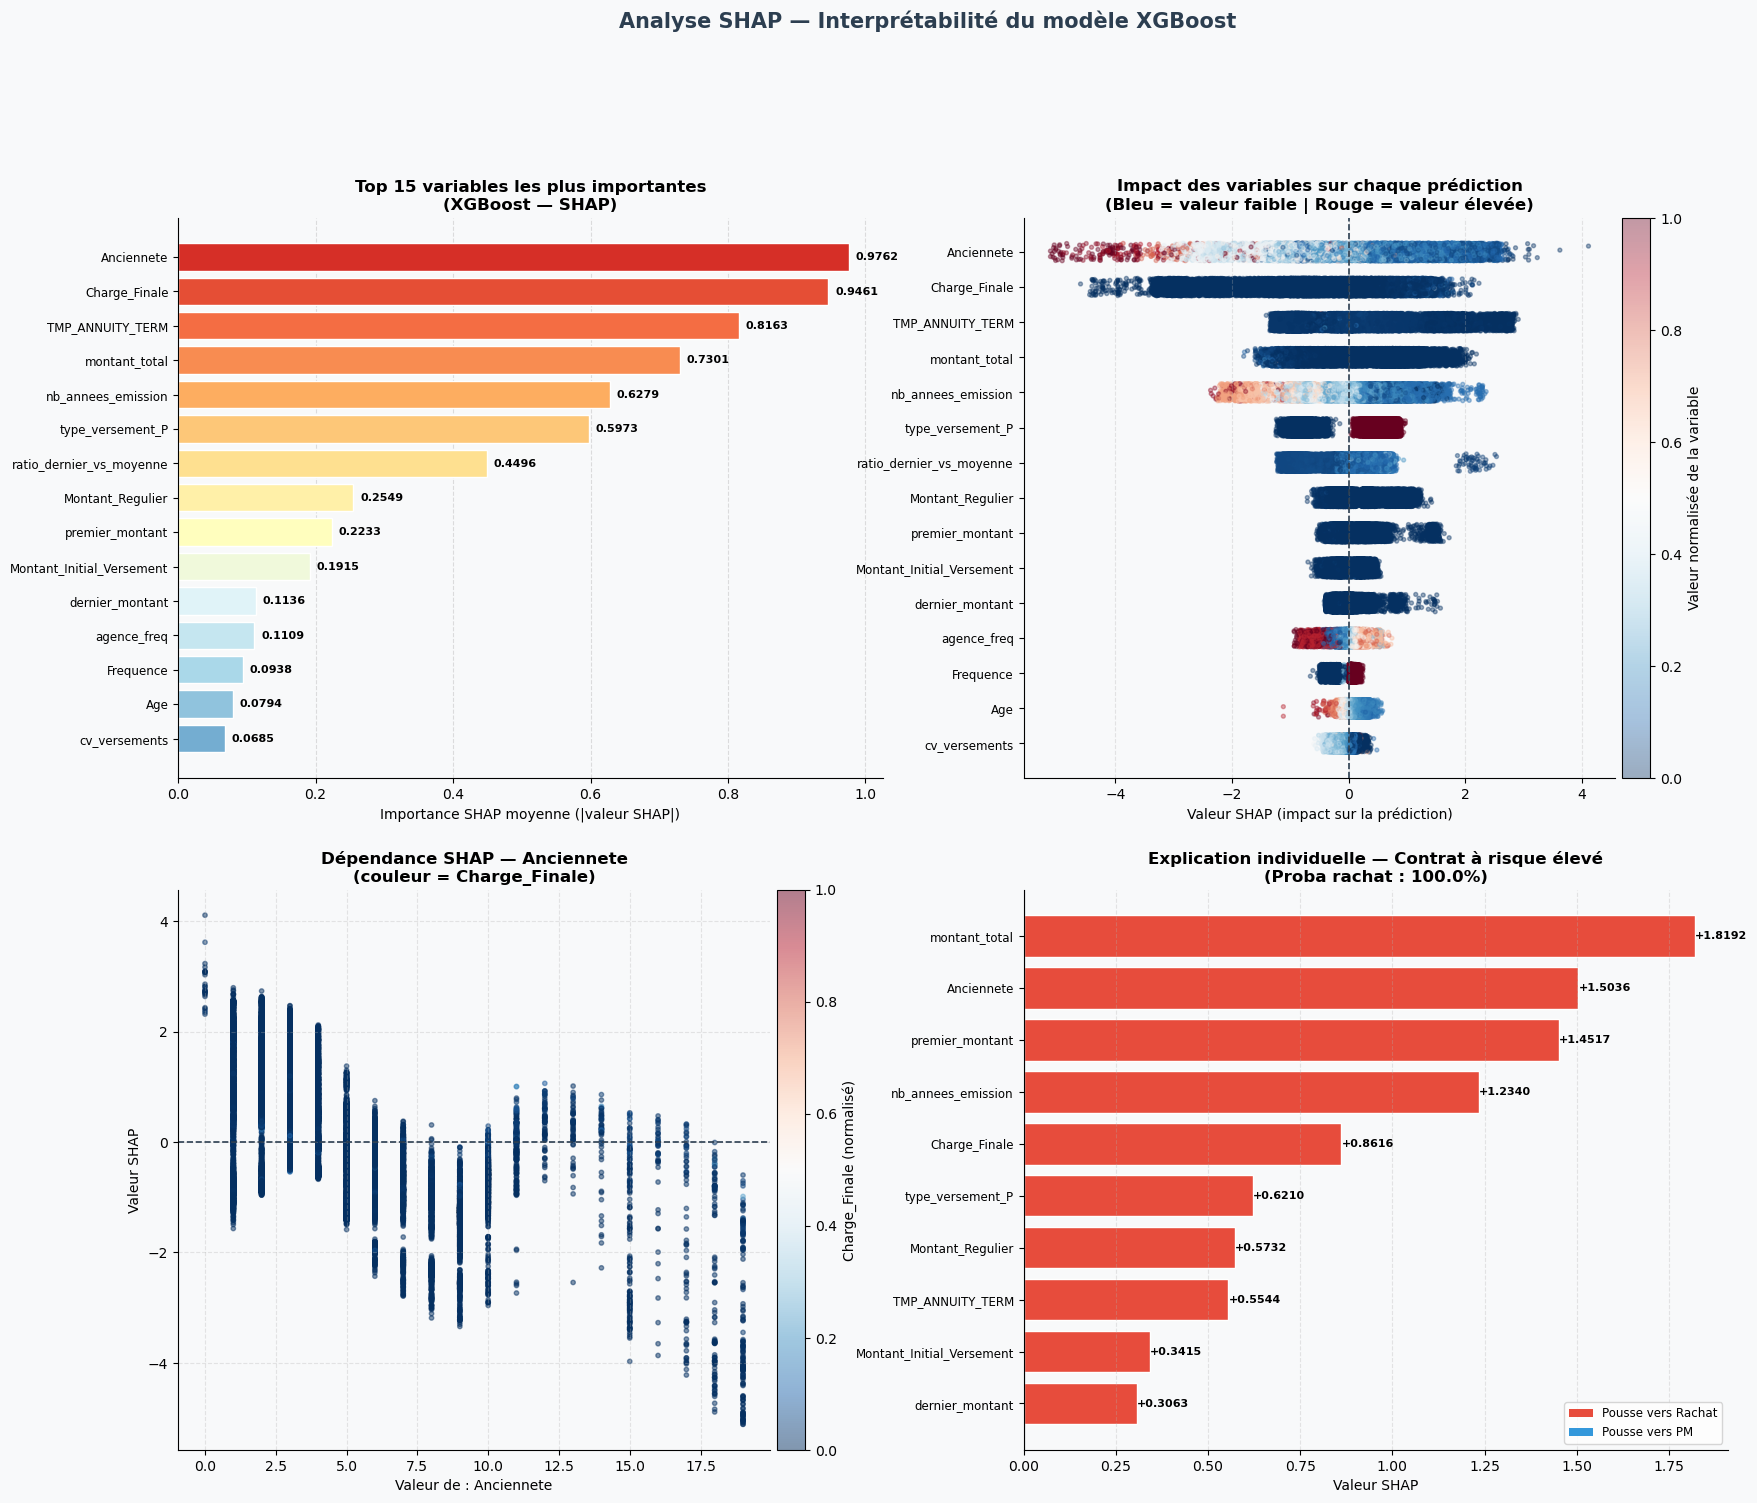

Graphique sauvegardé : analyse_shap.png


In [11]:
# ============================================================
# CELLULE 6 : ANALYSE SHAP — INTERPRÉTABILITÉ DU MEILLEUR MODÈLE
# À exécuter après la cellule 5
# Choisit automatiquement le modèle avec le meilleur AUC
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# SÉLECTION AUTOMATIQUE DU MEILLEUR MODÈLE
# ============================================================

# Récupérer le modèle avec le meilleur AUC-ROC sur le test set
meilleur_nom = max(resultats, key=lambda n: resultats[n]['auc'])
meilleur     = resultats[meilleur_nom]['modele']

print(f"Meilleur modèle : {meilleur_nom}")
print(f"AUC-ROC         : {resultats[meilleur_nom]['auc']:.4f}")

# Données d'entraînement adaptées (normalisées si LR)
if meilleur_nom == 'Régression Logistique':
    Xtr_shap = pd.DataFrame(X_train_sc, columns=X_train.columns)
    Xte_shap = pd.DataFrame(X_test_sc,  columns=X_test.columns)
else:
    Xtr_shap = X_train
    Xte_shap = X_test

# ============================================================
# CALCUL DES VALEURS SHAP
# ============================================================

print("\nCalcul des valeurs SHAP (peut prendre 1-2 minutes)...")

if meilleur_nom == 'XGBoost':
    explainer   = shap.TreeExplainer(meilleur)
    shap_values = explainer.shap_values(Xte_shap)
elif meilleur_nom == 'Random Forest':
    explainer   = shap.TreeExplainer(meilleur)
    shap_values = explainer.shap_values(Xte_shap)
    # RF retourne [shap_class0, shap_class1] → on prend classe 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    # Régression Logistique → LinearExplainer
    explainer   = shap.LinearExplainer(meilleur, Xtr_shap)
    shap_values = explainer.shap_values(Xte_shap)

print("Valeurs SHAP calculées.")

# ============================================================
# VISUALISATION SHAP — 4 graphiques
# ============================================================

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#F8F9FA')

# ------------------------------------------------------------------
# GRAPHIQUE 1 : Importance globale SHAP (mean |SHAP|)
# ------------------------------------------------------------------
ax1 = fig.add_subplot(2, 2, 1)
ax1.set_facecolor('#F8F9FA')

shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=Xte_shap.columns
).sort_values(ascending=True)

# Top 15
top15 = shap_importance.tail(15)
colors_imp = plt.cm.RdYlBu_r(np.linspace(0.2, 0.9, len(top15)))

bars = ax1.barh(top15.index, top15.values, color=colors_imp, edgecolor='white')
ax1.set_xlabel('Importance SHAP moyenne (|valeur SHAP|)', fontsize=10)
ax1.set_title(f'Top 15 variables les plus importantes\n({meilleur_nom} — SHAP)',
              fontsize=12, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)
ax1.xaxis.grid(True, linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)
ax1.tick_params(axis='y', labelsize=8.5)

for bar, val in zip(bars, top15.values):
    ax1.text(val + top15.max()*0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8, fontweight='bold')

# ------------------------------------------------------------------
# GRAPHIQUE 2 : Beeswarm (summary plot) — top 15 variables
# ------------------------------------------------------------------
ax2 = fig.add_subplot(2, 2, 2)
ax2.set_facecolor('#F8F9FA')

top15_vars  = shap_importance.tail(15).index.tolist()
idx_top15   = [list(Xte_shap.columns).index(v) for v in top15_vars]
shap_top15  = shap_values[:, idx_top15]
X_top15     = Xte_shap[top15_vars].values

# Beeswarm manuel
for i, var in enumerate(top15_vars):
    sv   = shap_top15[:, i]
    xv   = X_top15[:, i]
    # Normaliser les valeurs pour la couleur
    xv_norm = (xv - xv.min()) / (xv.max() - xv.min() + 1e-9)
    # Jitter vertical
    jitter = np.random.uniform(-0.25, 0.25, size=len(sv))
    sc = ax2.scatter(sv, np.full(len(sv), i) + jitter,
                     c=xv_norm, cmap='RdBu_r', alpha=0.4, s=8,
                     vmin=0, vmax=1)

ax2.axvline(x=0, color='#2C3E50', linewidth=1.2, linestyle='--')
ax2.set_yticks(range(len(top15_vars)))
ax2.set_yticklabels(top15_vars, fontsize=8.5)
ax2.set_xlabel('Valeur SHAP (impact sur la prédiction)', fontsize=10)
ax2.set_title('Impact des variables sur chaque prédiction\n(Bleu = valeur faible | Rouge = valeur élevée)',
              fontsize=12, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)
ax2.xaxis.grid(True, linestyle='--', alpha=0.3)
plt.colorbar(sc, ax=ax2, label='Valeur normalisée de la variable', pad=0.01)

# ------------------------------------------------------------------
# GRAPHIQUE 3 : Dépendance SHAP pour la variable la plus importante
# ------------------------------------------------------------------
ax3 = fig.add_subplot(2, 2, 3)
ax3.set_facecolor('#F8F9FA')

var_top1   = shap_importance.index[-1]
idx_top1   = list(Xte_shap.columns).index(var_top1)
sv_top1    = shap_values[:, idx_top1]
xv_top1    = Xte_shap[var_top1].values

# Couleur par 2ème variable la plus importante
var_top2   = shap_importance.index[-2]
xv_top2    = Xte_shap[var_top2].values
xv2_norm   = (xv_top2 - xv_top2.min()) / (xv_top2.max() - xv_top2.min() + 1e-9)

sc3 = ax3.scatter(xv_top1, sv_top1, c=xv2_norm, cmap='RdBu_r',
                   alpha=0.5, s=10)
ax3.axhline(y=0, color='#2C3E50', linewidth=1.2, linestyle='--')
ax3.set_xlabel(f'Valeur de : {var_top1}', fontsize=10)
ax3.set_ylabel('Valeur SHAP', fontsize=10)
ax3.set_title(f'Dépendance SHAP — {var_top1}\n(couleur = {var_top2})',
              fontsize=12, fontweight='bold')
ax3.spines[['top', 'right']].set_visible(False)
ax3.grid(True, linestyle='--', alpha=0.3)
plt.colorbar(sc3, ax=ax3, label=f'{var_top2} (normalisé)', pad=0.01)

# ------------------------------------------------------------------
# GRAPHIQUE 4 : Waterfall pour un contrat "type" à risque de rachat
# ------------------------------------------------------------------
ax4 = fig.add_subplot(2, 2, 4)
ax4.set_facecolor('#F8F9FA')

# Trouver le contrat avec la proba de rachat la plus élevée
y_proba_best = resultats[meilleur_nom]['y_proba']
idx_high     = np.argsort(y_proba_best)[-1]

# Top 10 variables SHAP pour ce contrat
sv_contrat   = shap_values[idx_high]
top10_idx    = np.argsort(np.abs(sv_contrat))[-10:]
top10_vars_w = [Xte_shap.columns[i] for i in top10_idx]
top10_sv_w   = sv_contrat[top10_idx]

colors_wf = ['#E74C3C' if v > 0 else '#3498DB' for v in top10_sv_w]
ax4.barh(top10_vars_w, top10_sv_w, color=colors_wf, edgecolor='white')
ax4.axvline(x=0, color='#2C3E50', linewidth=1.5)

for i, (var, val) in enumerate(zip(top10_vars_w, top10_sv_w)):
    txt = f'+{val:.4f}' if val > 0 else f'{val:.4f}'
    ax4.text(val + (0.001 if val >= 0 else -0.001), i,
             txt, va='center',
             ha='left' if val >= 0 else 'right',
             fontsize=8, fontweight='bold')

ax4.set_xlabel('Valeur SHAP', fontsize=10)
ax4.set_title(f'Explication individuelle — Contrat à risque élevé\n'
              f'(Proba rachat : {y_proba_best[idx_high]*100:.1f}%)',
              fontsize=12, fontweight='bold')
ax4.spines[['top', 'right']].set_visible(False)
ax4.xaxis.grid(True, linestyle='--', alpha=0.3)
ax4.tick_params(axis='y', labelsize=8.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E74C3C', label='Pousse vers Rachat'),
                   Patch(facecolor='#3498DB', label='Pousse vers PM')]
ax4.legend(handles=legend_elements, fontsize=8.5, loc='lower right')

# ------------------------------------------------------------------
# TITRE GÉNÉRAL
# ------------------------------------------------------------------
fig.suptitle(f'Analyse SHAP — Interprétabilité du modèle {meilleur_nom}',
             fontsize=15, fontweight='bold', color='#2C3E50', y=1.01)

plt.savefig('analyse_shap.png', dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Graphique sauvegardé : analyse_shap.png")

Modèle XGBoost récupéré
Features attendues (18) : ['Age', 'Anciennete', 'Charge_Finale', 'Frequence', 'Montant_Initial_Versement', 'Montant_Regulier', 'TMP_ANNUITY_TERM', 'agence_freq', 'cv_versements', 'dernier_montant', 'montant_total', 'moyenne_versements', 'nb_annees_emission', 'premier_montant', 'ratio_dernier_vs_moyenne', 'std_versements', 'tendance_versements', 'type_versement_P']

Contrats PM retenus : 69,694
Features alignées : (69694, 18)
Valeurs manquantes : 0

Scores calculés pour 69,694 contrats

RÉSUMÉ DU SCORING PM
Total contrats scorés        : 69,694

Distribution catégorie risque :
  Élevé      : 21,291  (30.5%)
  Modéré     :  6,577  (9.4%)
  Faible     : 41,826  (60.0%)

Score moyen N+1 : 35.78%
Score moyen N+2 : 27.46%
Score moyen N+3 : 16.04%

Top 10 contrats les plus à risque :
 Rang      ID_Police  Age  Anciennete  Charge_Finale  proba_rachat_N1  proba_rachat_N2  proba_rachat_N3  score_risque_global categorie_risque
    1 14012400003030   30           1       44

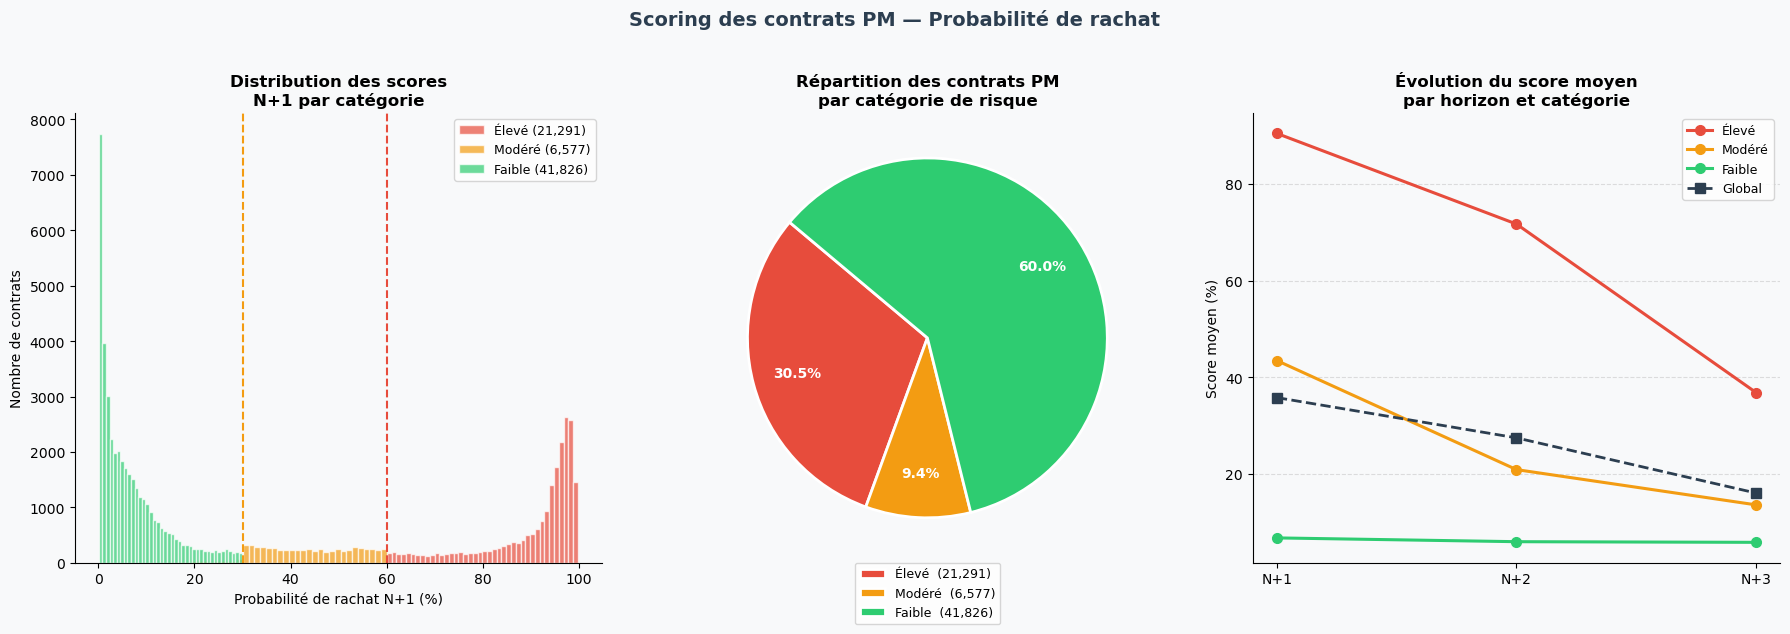

Graphique sauvegardé : scoring_pm.png

Fichier sauvegardé : scoring_contrats_pm.csv (69,694 contrats)


In [13]:
# ============================================================
# CELLULE 7 : SCORING DES CONTRATS PM
# Probabilité de rachat pour l'année prochaine et les suivantes
# Modèle : XGBoost (retenu à l'étape précédente)
# ============================================================
#
# COMMENT LE SCORE EST ATTRIBUÉ :
# ─────────────────────────────────────────────────────────────
# 1. On reprend le modèle XGBoost entraîné sur les contrats
#    Rachat (>= 2015) + PM avec émissions.
#
# 2. Pour chaque contrat PM, on simule 3 horizons temporels
#    en faisant vieillir le contrat :
#    - Horizon N+1 : Anciennete + 1  (l'année prochaine)
#    - Horizon N+2 : Anciennete + 2  (dans 2 ans)
#    - Horizon N+3 : Anciennete + 3  (dans 3 ans)
#
# 3. Pour chaque horizon, XGBoost retourne predict_proba(),
#    soit la probabilité que le contrat passe de PM à Rachat.
#    C'est une valeur entre 0 et 1 (multipliée par 100 = %).
#
# 4. On ajoute un score de risque global = max des 3 horizons,
#    et une catégorie de risque : Faible / Modéré / Élevé.
#
# Seuils de catégorisation :
#    Faible   : proba < 30%
#    Modéré   : 30% <= proba < 60%
#    Élevé    : proba >= 60%
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# ETAPE 1 : RÉCUPÉRER LE MODÈLE ET LES FEATURES
# (dépend de la cellule 5 — même kernel)
# ============================================================

# Récupérer XGBoost depuis le dict resultats de la cellule 5
modele_xgb = resultats['XGBoost']['modele']
features   = list(X_train.columns)  # liste des features utilisées

print(f"Modèle XGBoost récupéré")
print(f"Features attendues ({len(features)}) : {features}")

# ============================================================
# ETAPE 2 : PRÉPARER LES DONNÉES PM
# Même pipeline que cellule 2 (features_base) + cellule 1 (features_emissions)
# ============================================================

# --- Base ---
bar = pd.read_csv('Base_annee_rachat.csv', sep=None, engine='python')
bar.columns = bar.columns.str.strip().str.replace('\ufeff', '')
bar['ID_Police'] = bar['ID_Police'].astype(str)

ec = pd.read_csv('emission_annuelle_complete.csv', sep=None, engine='python')
ec.columns = ec.columns.str.strip().str.replace('\ufeff', '')
ec['ID_Police'] = ec['ID_Police'].astype(str)
emit_ids = set(ec['ID_Police'])

# Filtrer PM avec émissions uniquement
pm = bar[(bar['Rachat'] == 0) & (bar['ID_Police'].isin(emit_ids))].copy()
pm = pm.drop_duplicates(subset='ID_Police')
pm_ids = set(pm['ID_Police'])

print(f"\nContrats PM retenus : {len(pm):,}")

# --- Même nettoyage que cellule 2 ---
cols_a_supprimer = [
    'Date_Naissance', 'Debut', 'Fin', 'Annee_Effet',
    'TMP_ANNUITY_TERM', 'Ville', 'Beneficiaires',
    'année de rachat', 'Code_Postal'
]
pm = pm.drop(columns=[c for c in cols_a_supprimer if c in pm.columns])

# Imputation
for col in ['Montant_Initial_Versement', 'Montant_Regulier', 'Frequence']:
    if col in pm.columns:
        pm[col] = pm[col].fillna(pm[col].median())
pm['Agence'] = pm['Agence'].fillna('Inconnue')

# Encodage
pm['type_versement_P'] = (pm['Type_versement'] == 'P').astype(int)
pm = pm.drop(columns=['Type_versement'])

freq_agence = bar['Agence'].fillna('Inconnue').value_counts(normalize=True)
pm['agence_freq'] = pm['Agence'].map(freq_agence).fillna(0)
pm = pm.drop(columns=['Agence'])

# --- Émissions agrégées (même calcul que cellule 1) ---
from scipy import stats as scipy_stats

ec_pm = ec[ec['ID_Police'].isin(pm_ids)].copy()
ec_pm = ec_pm.sort_values(['ID_Police', 'annee'])

# Imputation montants = 0
def imputer_zeros(groupe):
    mediane_nonzero = groupe[groupe > 0].median()
    if pd.isna(mediane_nonzero):
        return groupe
    return groupe.where(groupe != 0, mediane_nonzero)

ec_pm['montant'] = ec_pm.groupby('ID_Police')['montant'].transform(imputer_zeros)

def calc_tendance(montants):
    if len(montants) < 2:
        return 0.0
    x = np.arange(len(montants))
    slope, _, _, _, _ = scipy_stats.linregress(x, montants)
    return round(slope, 4)

agg_pm = ec_pm.groupby('ID_Police').agg(
    moyenne_versements = ('montant', 'mean'),
    std_versements     = ('montant', 'std'),
    nb_annees_emission = ('annee',   'nunique'),
    dernier_montant    = ('montant', 'last'),
    premier_montant    = ('montant', 'first'),
    montant_total      = ('montant', 'sum'),
).reset_index()

tendance_pm = (
    ec_pm.groupby('ID_Police')['montant']
    .apply(lambda s: calc_tendance(s.values))
    .rename('tendance_versements').reset_index()
)
agg_pm = agg_pm.merge(tendance_pm, on='ID_Police', how='left')
agg_pm['std_versements'] = agg_pm['std_versements'].fillna(0)
agg_pm['ratio_dernier_vs_moyenne'] = np.where(
    agg_pm['moyenne_versements'] > 0,
    agg_pm['dernier_montant'] / agg_pm['moyenne_versements'], 0
)
agg_pm['cv_versements'] = np.where(
    agg_pm['moyenne_versements'] > 0,
    agg_pm['std_versements'] / agg_pm['moyenne_versements'], 0
)

# PM n'ont pas de N-1 → hausse/chute = 0
agg_pm['hausse_exceptionnelle'] = 0
agg_pm['chute_brutale']         = 0

# --- Fusion base + émissions ---
pm_full = pm.merge(agg_pm, on='ID_Police', how='left')

# Remplir NaN émissions par 0
cols_emit = [c for c in agg_pm.columns if c != 'ID_Police']
pm_full[cols_emit] = pm_full[cols_emit].fillna(0)

# Aligner les colonnes exactement sur ce qu'attend XGBoost
# Ajouter colonnes manquantes à 0, supprimer les colonnes en trop
for col in features:
    if col not in pm_full.columns:
        pm_full[col] = 0

pm_full = pm_full.drop(columns=['Rachat'], errors='ignore')
X_pm    = pm_full[features].copy()

print(f"Features alignées : {X_pm.shape}")
print(f"Valeurs manquantes : {X_pm.isnull().sum().sum()}")

# ============================================================
# ETAPE 3 : SCORING SUR 3 HORIZONS TEMPORELS
# On simule le vieillissement du contrat en incrémentant Anciennete
# ============================================================

scores = pm_full[['ID_Police']].copy()

for horizon in [1, 2, 3]:
    X_horizon = X_pm.copy()

    # Vieillir le contrat
    if 'Anciennete' in X_horizon.columns:
        X_horizon['Anciennete'] = X_horizon['Anciennete'] + horizon

    # Predict_proba → probabilité de rachat (classe 1)
    proba = modele_xgb.predict_proba(X_horizon)[:, 1]
    scores[f'proba_rachat_N{horizon}'] = (proba * 100).round(2)

print(f"\nScores calculés pour {len(scores):,} contrats")

# ============================================================
# ETAPE 4 : SCORE GLOBAL ET CATÉGORIE DE RISQUE
# ============================================================

# Score global = maximum des 3 horizons (pire cas)
scores['score_risque_global'] = scores[
    ['proba_rachat_N1', 'proba_rachat_N2', 'proba_rachat_N3']
].max(axis=1).round(2)

# Catégorie de risque
def categoriser(score):
    if score >= 60:
        return 'Élevé'
    elif score >= 30:
        return 'Modéré'
    else:
        return 'Faible'

scores['categorie_risque'] = scores['score_risque_global'].apply(categoriser)

# ============================================================
# ETAPE 5 : ENRICHIR AVEC LES INFOS DU CONTRAT
# ============================================================

infos = bar[bar['Rachat'] == 0][
    ['ID_Police', 'Age', 'Anciennete', 'Charge_Finale',
     'Montant_Initial_Versement', 'Montant_Regulier',
     'Type_versement', 'Annee_Effet']
].drop_duplicates(subset='ID_Police')

scores = scores.merge(infos, on='ID_Police', how='left')

# Trier par score global décroissant
scores = scores.sort_values('score_risque_global', ascending=False).reset_index(drop=True)
scores.insert(0, 'Rang', range(1, len(scores) + 1))

# ============================================================
# ETAPE 6 : RÉSUMÉ
# ============================================================

print("\n" + "="*55)
print("RÉSUMÉ DU SCORING PM")
print("="*55)
print(f"Total contrats scorés        : {len(scores):,}")
print(f"\nDistribution catégorie risque :")
dist = scores['categorie_risque'].value_counts()
for cat in ['Élevé', 'Modéré', 'Faible']:
    n   = dist.get(cat, 0)
    pct = n / len(scores) * 100
    print(f"  {cat:<10} : {n:>6,}  ({pct:.1f}%)")

print(f"\nScore moyen N+1 : {scores['proba_rachat_N1'].mean():.2f}%")
print(f"Score moyen N+2 : {scores['proba_rachat_N2'].mean():.2f}%")
print(f"Score moyen N+3 : {scores['proba_rachat_N3'].mean():.2f}%")

print(f"\nTop 10 contrats les plus à risque :")
print(scores[['Rang', 'ID_Police', 'Age', 'Anciennete', 'Charge_Finale',
              'proba_rachat_N1', 'proba_rachat_N2', 'proba_rachat_N3',
              'score_risque_global', 'categorie_risque']].head(10).to_string(index=False))

# ============================================================
# ETAPE 7 : VISUALISATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#F8F9FA')

COLORS_CAT = {'Élevé': '#E74C3C', 'Modéré': '#F39C12', 'Faible': '#2ECC71'}

# --- Graphique 1 : Distribution des scores N+1 par catégorie ---
ax1 = axes[0]
ax1.set_facecolor('#F8F9FA')
for cat, color in COLORS_CAT.items():
    subset = scores[scores['categorie_risque'] == cat]['proba_rachat_N1']
    ax1.hist(subset, bins=40, alpha=0.7, color=color, label=f'{cat} ({len(subset):,})',
             edgecolor='white')
ax1.axvline(30, color='#F39C12', linestyle='--', linewidth=1.5)
ax1.axvline(60, color='#E74C3C', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Probabilité de rachat N+1 (%)', fontsize=10)
ax1.set_ylabel('Nombre de contrats', fontsize=10)
ax1.set_title('Distribution des scores\nN+1 par catégorie', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# --- Graphique 2 : Camembert des catégories ---
ax2 = axes[1]
ax2.set_facecolor('#F8F9FA')
cats   = ['Élevé', 'Modéré', 'Faible']
counts = [dist.get(c, 0) for c in cats]
colors = [COLORS_CAT[c] for c in cats]
wedges, texts, autotexts = ax2.pie(
    counts, labels=None, colors=colors,
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')
legend_labels = [f"{c}  ({n:,})" for c, n in zip(cats, counts)]
ax2.legend(wedges, legend_labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.15), fontsize=9)
ax2.set_title('Répartition des contrats PM\npar catégorie de risque', fontsize=12, fontweight='bold')

# --- Graphique 3 : Évolution du score moyen par horizon ---
ax3 = axes[2]
ax3.set_facecolor('#F8F9FA')
horizons    = ['N+1', 'N+2', 'N+3']
moy_globale = [scores['proba_rachat_N1'].mean(),
               scores['proba_rachat_N2'].mean(),
               scores['proba_rachat_N3'].mean()]
for cat, color in COLORS_CAT.items():
    sub = scores[scores['categorie_risque'] == cat]
    moy = [sub['proba_rachat_N1'].mean(),
           sub['proba_rachat_N2'].mean(),
           sub['proba_rachat_N3'].mean()]
    ax3.plot(horizons, moy, marker='o', color=color,
             linewidth=2.2, markersize=7, label=cat)

ax3.plot(horizons, moy_globale, marker='s', color='#2C3E50',
         linewidth=2, markersize=7, linestyle='--', label='Global')
ax3.set_ylabel('Score moyen (%)', fontsize=10)
ax3.set_title('Évolution du score moyen\npar horizon et catégorie', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)
ax3.yaxis.grid(True, linestyle='--', alpha=0.4)
ax3.set_axisbelow(True)

fig.suptitle('Scoring des contrats PM — Probabilité de rachat',
             fontsize=14, fontweight='bold', color='#2C3E50', y=1.02)
plt.tight_layout()
plt.savefig('scoring_pm.png', dpi=150, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Graphique sauvegardé : scoring_pm.png")

# ============================================================
# ETAPE 8 : EXPORT CSV
# ============================================================

cols_export = [
    'Rang', 'ID_Police', 'Age', 'Anciennete', 'Annee_Effet',
    'Charge_Finale', 'Montant_Initial_Versement', 'Montant_Regulier',
    'Type_versement', 'proba_rachat_N1', 'proba_rachat_N2',
    'proba_rachat_N3', 'score_risque_global', 'categorie_risque'
]
cols_export = [c for c in cols_export if c in scores.columns]
scores[cols_export].to_csv('scoring_contrats_pm.csv', index=False)
print(f"\nFichier sauvegardé : scoring_contrats_pm.csv ({len(scores):,} contrats)")